In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from imblearn.over_sampling import SMOTE 
import optuna
from sklearn.metrics import accuracy_score, precision_score, f1_score, r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from sklearn.ensemble import BaggingRegressor, BaggingClassifier, GradientBoostingRegressor, GradientBoostingClassifier, StackingRegressor, StackingClassifier

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

from xgboost import XGBClassifier, XGBRegressor

from lightgbm import LGBMClassifier, LGBMRegressor

from catboost import CatBoostClassifier, CatBoostRegressor

RANDOM_STATE = 42

class_cv = StratifiedKFold(5, shuffle = True, random_state = RANDOM_STATE)
reg_cv = KFold(5, shuffle = True, random_state = RANDOM_STATE)

**Загрузка датасетов**

In [22]:
class_df = pd.read_csv("../csv/cl_finished.csv", sep = ";")
X_class = class_df.drop(columns = "Diabetes_012")
y_class = class_df["Diabetes_012"]

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_class, y_class, test_size = 0.3, stratify = y_class, random_state = RANDOM_STATE)

In [23]:
regress_df = pd.read_csv("../csv/winequality_finished.csv", sep = ";")
X_reg = regress_df.drop(columns = "quality")
y_reg = regress_df["quality"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = RANDOM_STATE)

**Модели решающих деревьев**

In [24]:

def objective_trees(trial, model_type):
    if model_type == "classification":
        max_depth = trial.suggest_int("max_depth", 2, 64)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 32)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 32)

        criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

        model = DecisionTreeClassifier(max_depth = max_depth, min_samples_split = min_samples_split, 
                                            min_samples_leaf = min_samples_leaf, criterion = criterion, random_state = RANDOM_STATE)
        
        score = cross_val_score(model, X_class_train, y_class_train, cv=class_cv, scoring="accuracy").mean()
        
        return score

    
    if model_type == "regression":

        max_depth = trial.suggest_int("max_depth", 2, 64)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 16)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 16)

        criterion = trial.suggest_categorical("criterion", ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'])

        model = DecisionTreeRegressor(max_depth = max_depth, min_samples_split = min_samples_split, 
                                            min_samples_leaf = min_samples_leaf, criterion = criterion, random_state = RANDOM_STATE)

        score = cross_val_score(model, X_reg_train, y_reg_train, cv = reg_cv, scoring = "neg_mean_squared_error").mean()

        return score

In [25]:
study_class = optuna.create_study(direction = "maximize")
study_class.optimize(lambda trial: objective_trees(trial, "classification"), n_trials = 25)

best_class_tree_model = DecisionTreeClassifier(**study_class.best_params, random_state = RANDOM_STATE)
best_class_tree_model.fit(X_class_train, y_class_train)

[I 2026-05-23 10:53:01,741] A new study created in memory with name: no-name-5be3718d-b1dd-4b48-972c-17c5a543bf42
[I 2026-05-23 10:53:03,642] Trial 0 finished with value: 0.826206432721702 and parameters: {'max_depth': 44, 'min_samples_split': 7, 'min_samples_leaf': 23, 'criterion': 'log_loss'}. Best is trial 0 with value: 0.826206432721702.
[I 2026-05-23 10:53:05,470] Trial 1 finished with value: 0.8245340244533279 and parameters: {'max_depth': 20, 'min_samples_split': 11, 'min_samples_leaf': 20, 'criterion': 'log_loss'}. Best is trial 0 with value: 0.826206432721702.
[I 2026-05-23 10:53:07,204] Trial 2 finished with value: 0.8220036467531742 and parameters: {'max_depth': 47, 'min_samples_split': 32, 'min_samples_leaf': 19, 'criterion': 'gini'}. Best is trial 0 with value: 0.826206432721702.
[I 2026-05-23 10:53:08,881] Trial 3 finished with value: 0.8204245035058427 and parameters: {'max_depth': 15, 'min_samples_split': 11, 'min_samples_leaf': 12, 'criterion': 'gini'}. Best is trial 0

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,4
,min_samples_leaf,24
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
pred = best_class_tree_model.predict(X_class_test)
print(f"Accuracy: {accuracy_score(y_class_test, pred)}")
print(f"Precision: {precision_score(y_class_test, pred, average = "weighted")}")
print(f"F1 score: {f1_score(y_class_test, pred, average = "weighted")}")

Accuracy: 0.8337564372234714
Precision: 0.785170013706016
F1 score: 0.784713536118605


C:\Users\zuzin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


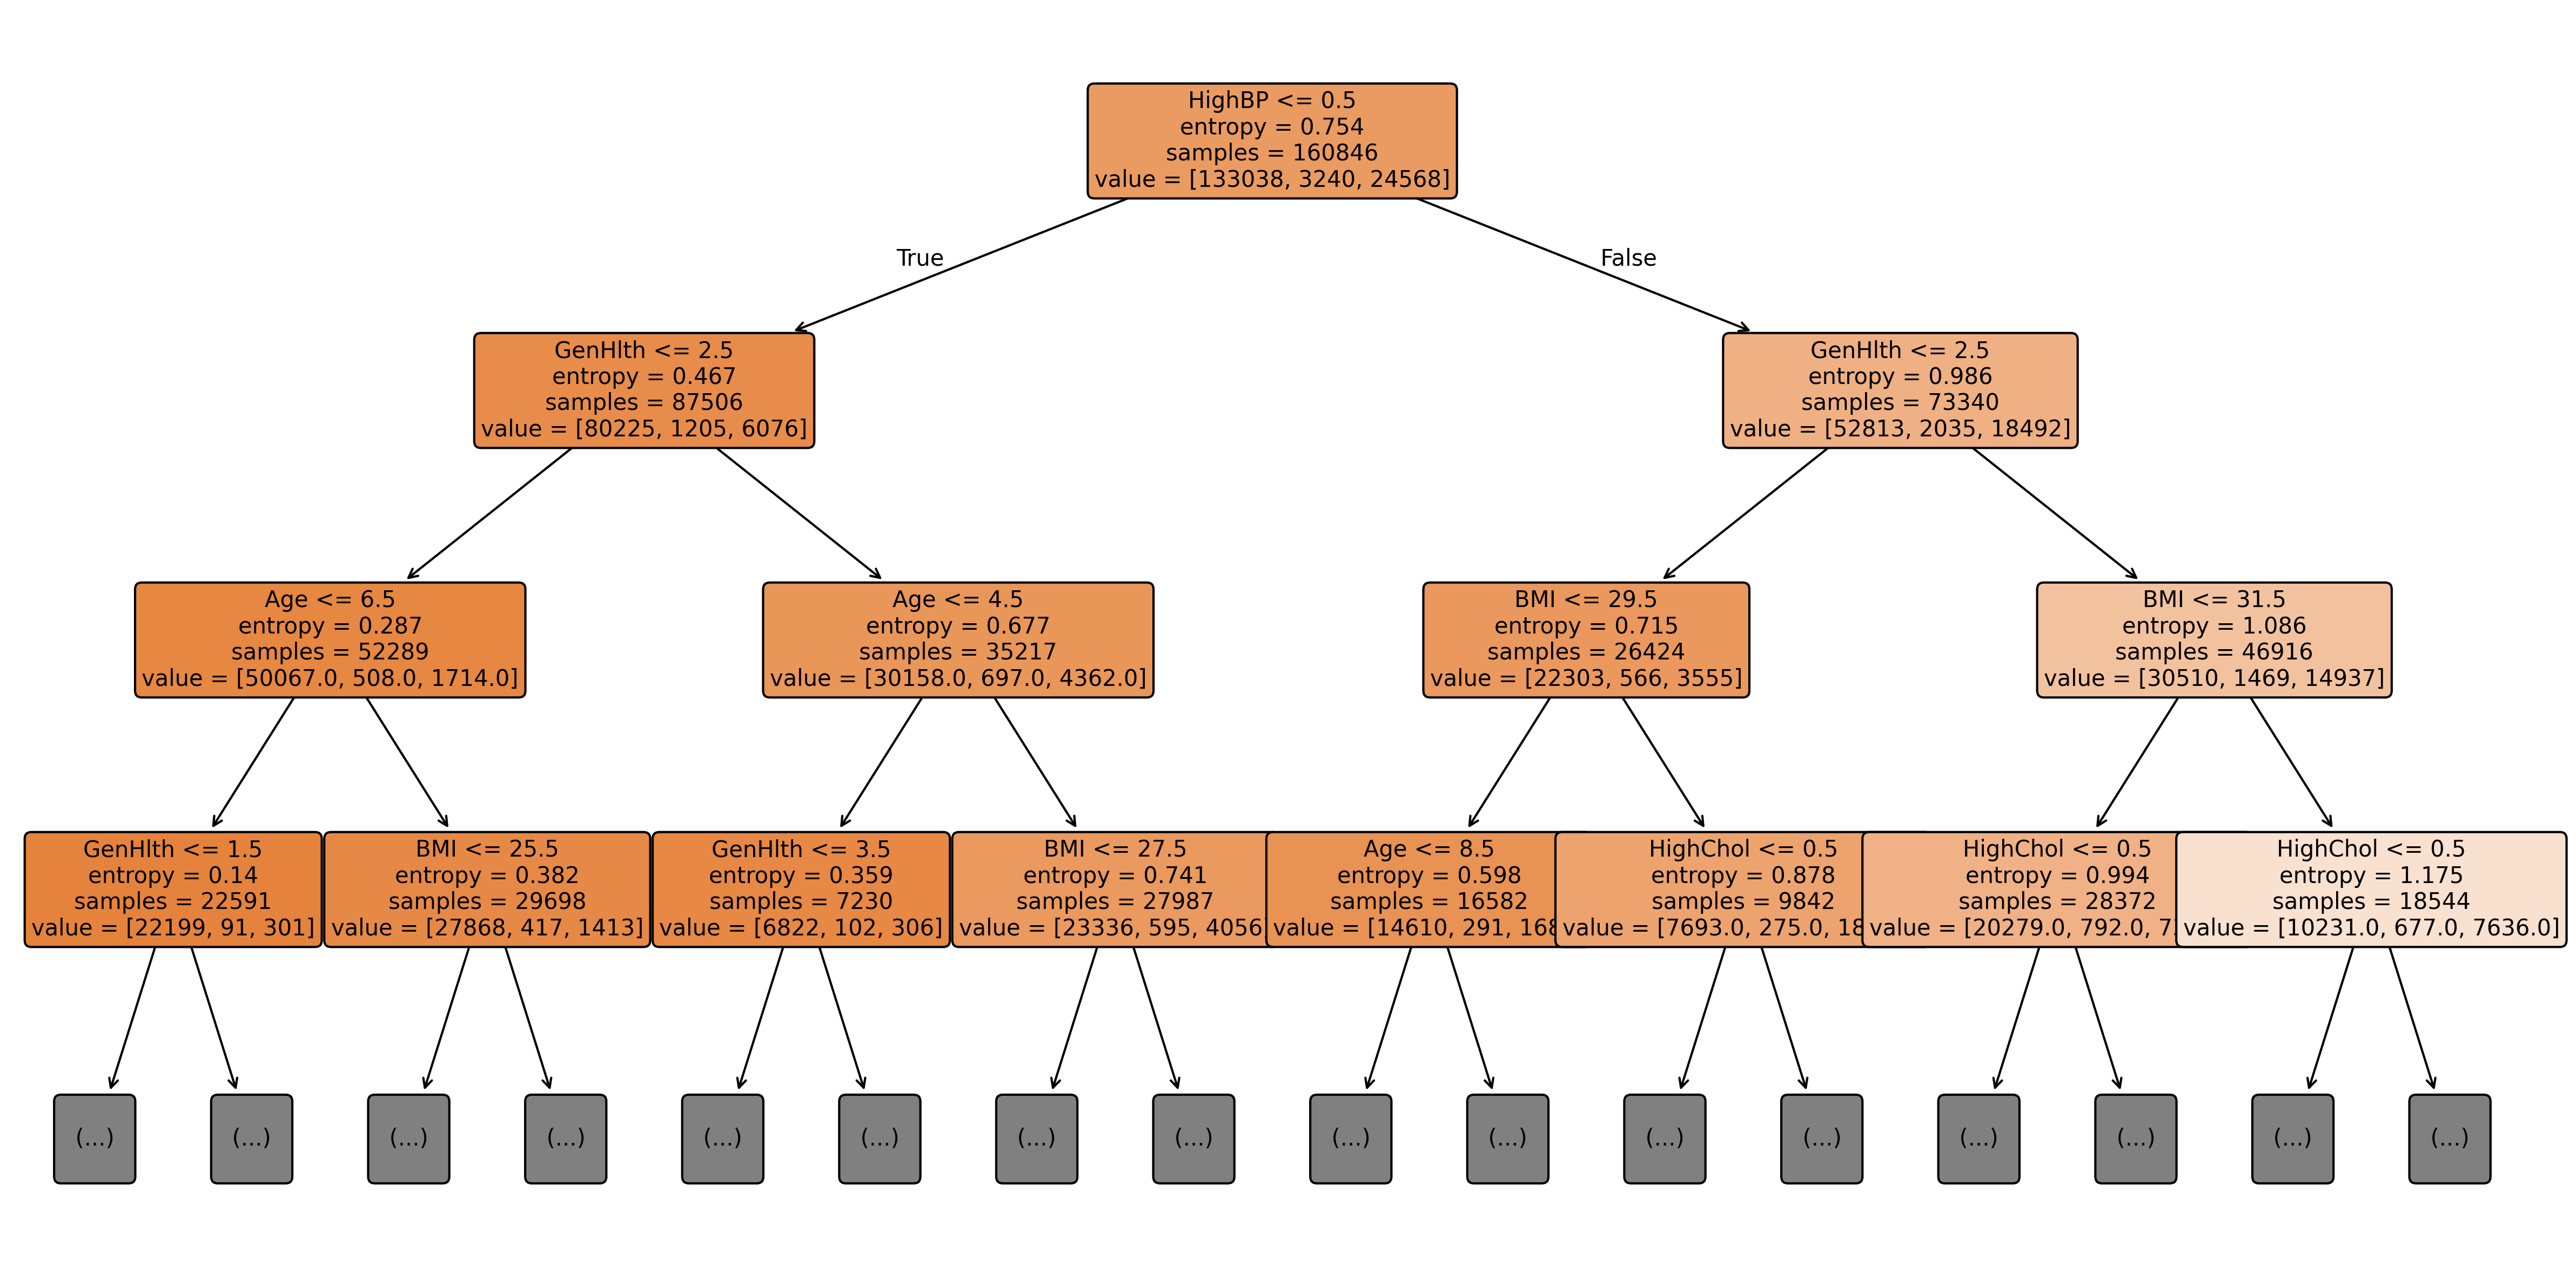

In [27]:
plt.figure(figsize=(20, 10), dpi=300)

plot_tree(
    best_class_tree_model,
    max_depth=3,
    feature_names=X_class.columns,
    filled=True,
    rounded=True,
    fontsize=10,
)

plt.show()

In [31]:
study_reg = optuna.create_study(direction = "maximize")
study_reg.optimize(lambda trial: objective_trees(trial, "regression"), n_trials = 100)

best_reg_tree_model = DecisionTreeRegressor(**study_reg.best_params, random_state = RANDOM_STATE)
best_reg_tree_model.fit(X_reg_train, y_reg_train)

[I 2026-05-23 10:54:06,861] A new study created in memory with name: no-name-04f6827d-1bd5-4d8e-941b-ccaa5ece03c2
[I 2026-05-23 10:54:06,954] Trial 0 finished with value: -0.5740716641873564 and parameters: {'max_depth': 30, 'min_samples_split': 6, 'min_samples_leaf': 11, 'criterion': 'friedman_mse'}. Best is trial 0 with value: -0.5740716641873564.
[I 2026-05-23 10:54:06,983] Trial 1 finished with value: -0.5974486177516483 and parameters: {'max_depth': 2, 'min_samples_split': 6, 'min_samples_leaf': 16, 'criterion': 'friedman_mse'}. Best is trial 0 with value: -0.5740716641873564.
[I 2026-05-23 10:54:07,113] Trial 2 finished with value: -0.6538063581996503 and parameters: {'max_depth': 41, 'min_samples_split': 12, 'min_samples_leaf': 3, 'criterion': 'poisson'}. Best is trial 0 with value: -0.5740716641873564.
[I 2026-05-23 10:54:11,214] Trial 3 finished with value: -0.7372442244224423 and parameters: {'max_depth': 34, 'min_samples_split': 11, 'min_samples_leaf': 3, 'criterion': 'absol

,criterion,'squared_error'
,splitter,'best'
,max_depth,7
,min_samples_split,4
,min_samples_leaf,12
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [35]:
pred_reg = best_reg_tree_model.predict(X_reg_test)

print(f"R2: {r2_score(y_reg_test, pred_reg)}")
print(f"MSE: {mean_squared_error(y_reg_test, pred_reg)}")
print(f"MAE: {mean_absolute_error(y_reg_test, pred_reg)}")
print(f"MAPE: {mean_absolute_percentage_error(y_reg_test, pred_reg)}")

R2: 0.2572717763569794
MSE: 0.5419242015662643
MAE: 0.5704338117110136
MAPE: 0.10232644024304778


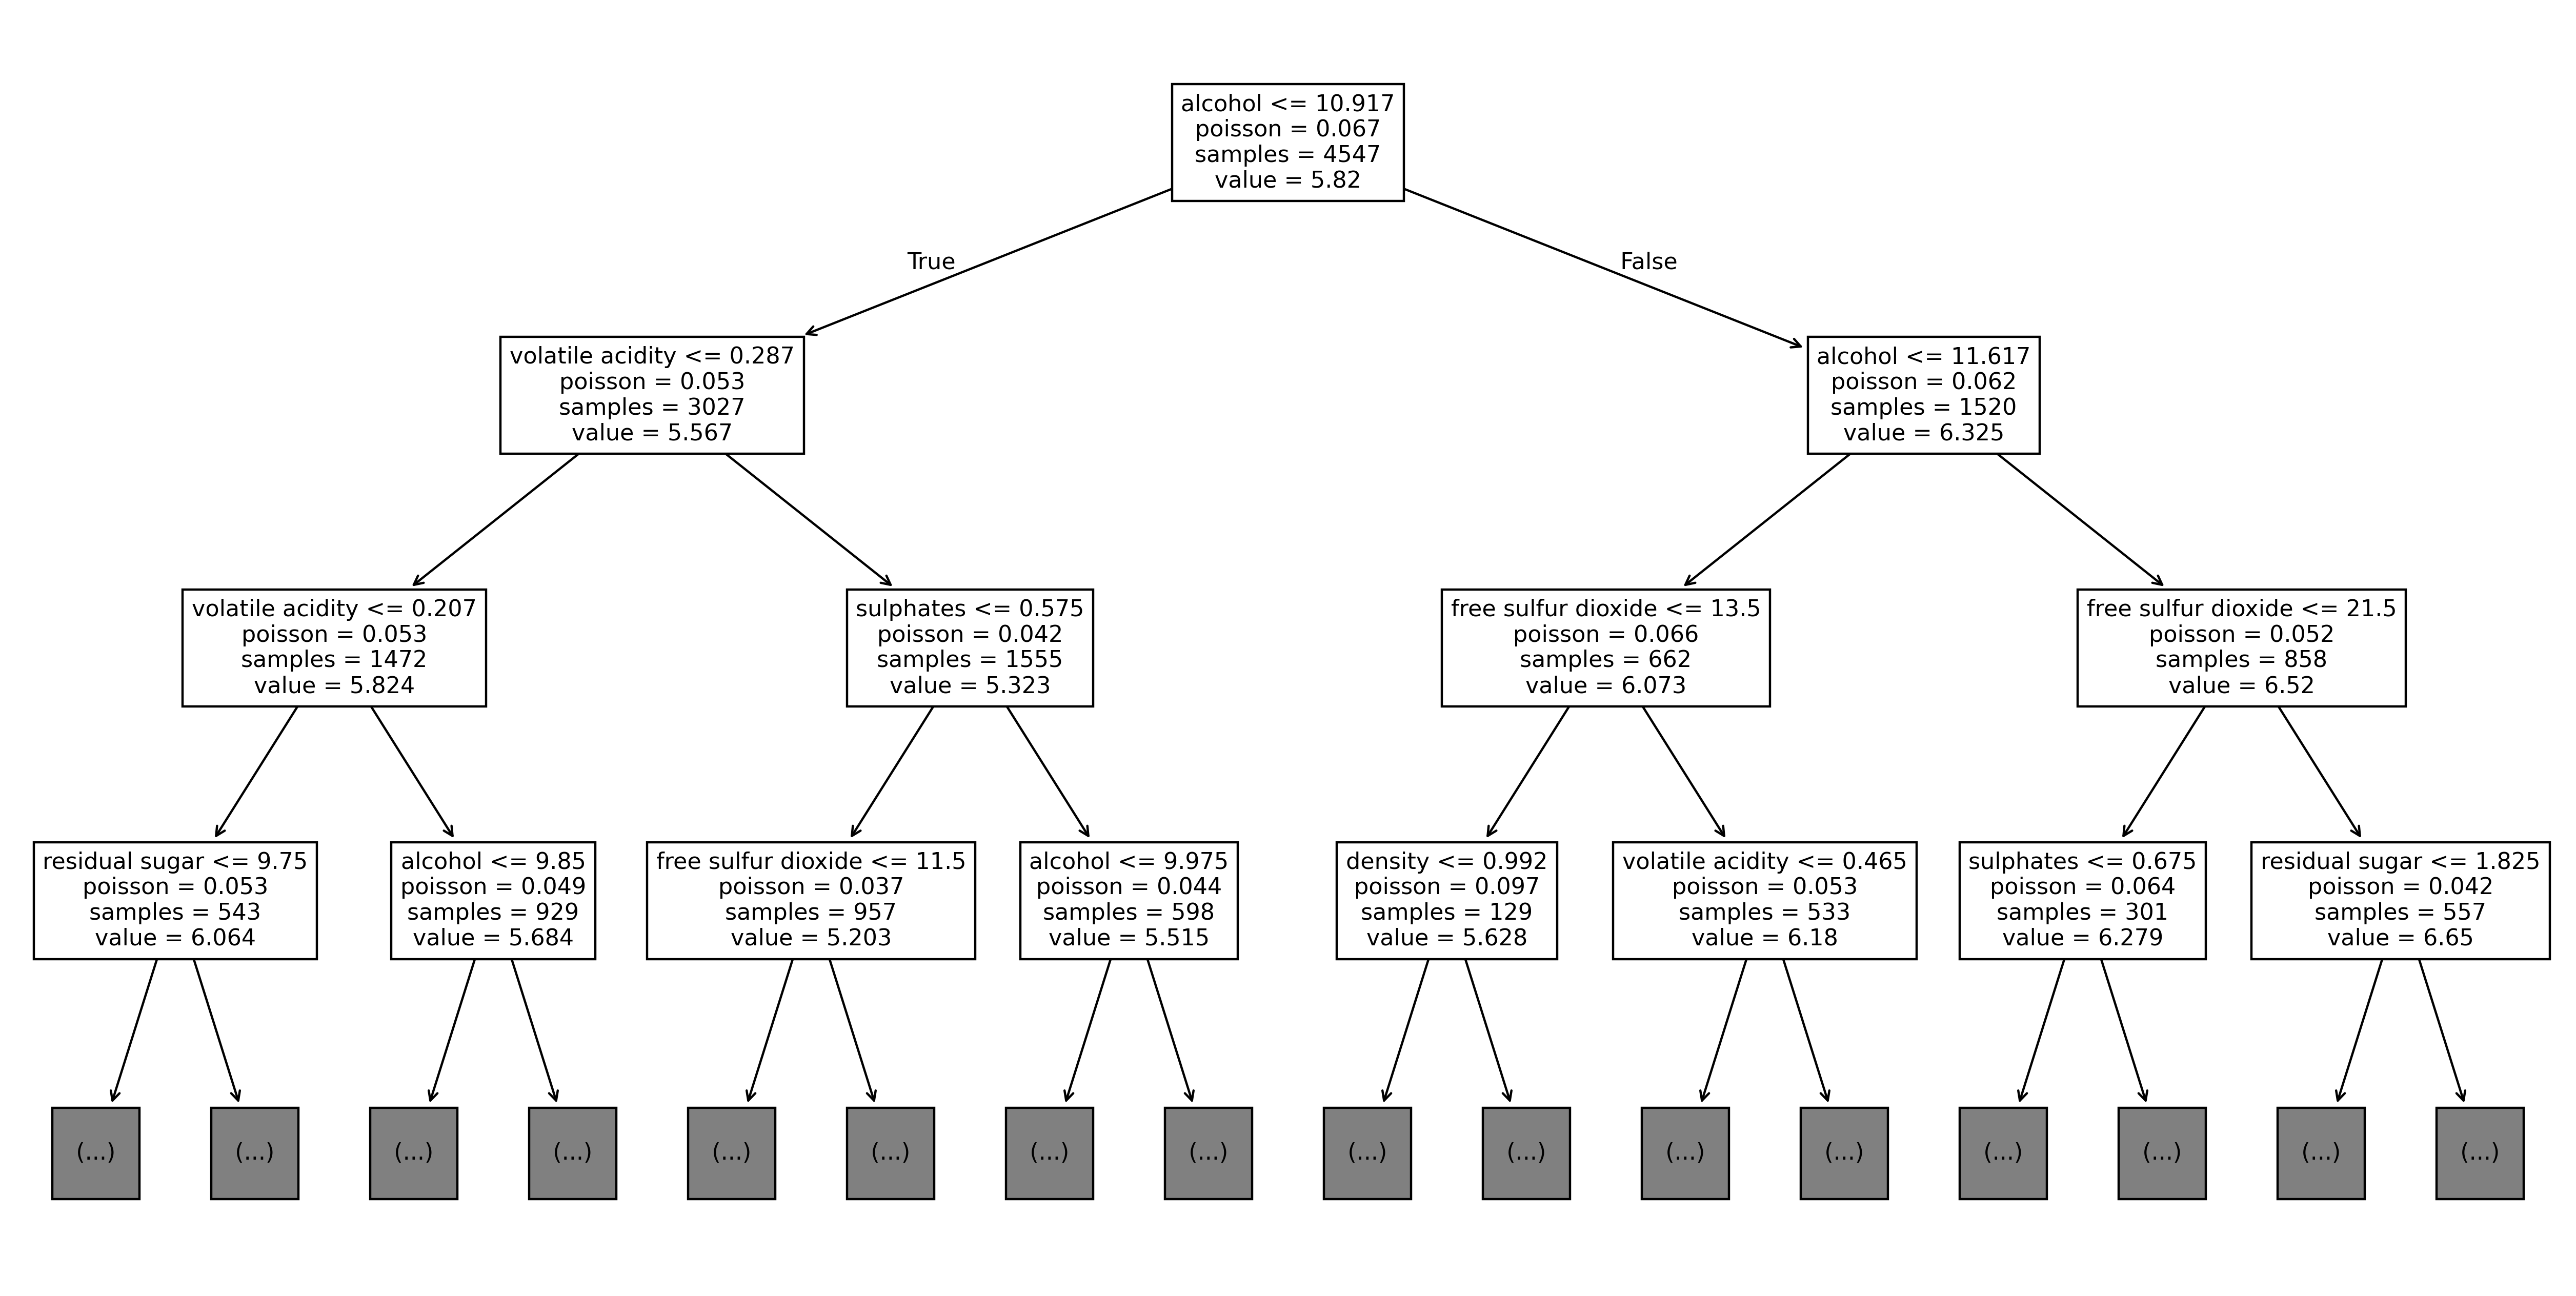

In [30]:
plt.figure(figsize = (20, 10), dpi = 320)

plot_tree(
    best_reg_tree_model,
    max_depth = 3,
    feature_names = X_reg.columns,
    fontsize = 10
)

plt.show()

**Модели ансамблей**